# IAIP — Indian Premier League Analysis & Insights Project
**Task 2 | EDA on Sports Data | Tool: Python**

This notebook performs a complete Exploratory Data Analysis on the IPL dataset:
- 756 matches across 12 seasons (2008–2019)
- 179,078 ball-by-ball deliveries
- Team success, player performance, and endorsement recommendations


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

matches = pd.read_csv('/content/matches.csv')
deliveries = pd.read_csv('/content/deliveries.csv')

print("✓ Ready! matches:", matches.shape)
print("✓ deliveries:", deliveries.shape)

✓ Ready! matches: (756, 18)
✓ deliveries: (179078, 21)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('charts', exist_ok=True)

matches = pd.read_csv('/content/matches.csv')
deliveries = pd.read_csv('/content/deliveries.csv')

print("✓ matches:", matches.shape)
print("✓ deliveries:", deliveries.shape)
print("✓ All libraries ready!")

✓ matches: (756, 18)
✓ deliveries: (179078, 21)
✓ All libraries ready!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})

matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print(f"Matches shape   : {matches.shape}")
print(f"Deliveries shape: {deliveries.shape}")
print(f"Seasons         : {sorted(matches['season'].unique())}")


Matches shape   : (756, 18)
Deliveries shape: (179078, 21)
Seasons         : [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]


## 1. Dataset Overview

In [ ]:
print("=== MATCHES DATASET ===")
print(matches.info())
print("\nSample rows:")
matches.head(3)


=== MATCHES DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   season           756 non-null    int64 
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3    

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN


In [ ]:
print("=== DELIVERIES DATASET ===")
print(deliveries.info())
deliveries.head(3)


=== DELIVERIES DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179078 entries, 0 to 179077
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          179078 non-null  int64 
 1   inning            179078 non-null  int64 
 2   batting_team      179078 non-null  object
 3   bowling_team      179078 non-null  object
 4   over              179078 non-null  int64 
 5   ball              179078 non-null  int64 
 6   batsman           179078 non-null  object
 7   non_striker       179078 non-null  object
 8   bowler            179078 non-null  object
 9   is_super_over     179078 non-null  int64 
 10  wide_runs         179078 non-null  int64 
 11  bye_runs          179078 non-null  int64 
 12  legbye_runs       179078 non-null  int64 
 13  noball_runs       179078 non-null  int64 
 14  penalty_runs      179078 non-null  int64 
 15  batsman_runs      179078 non-null  int64 
 16  extra_runs 

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN


In [ ]:
print("Missing values in matches:")
print(matches.isnull().sum()[matches.isnull().sum() > 0])
print("\nMissing values in deliveries:")
print(deliveries.isnull().sum()[deliveries.isnull().sum() > 0])


Missing values in matches:
city                 7
winner               4
player_of_match      4
umpire1              2
umpire2              2
umpire3            637
dtype: int64

Missing values in deliveries:
player_dismissed    170244
dismissal_kind      170244
fielder             172630
dtype: int64


## 2. Season-wise Match Distribution

In [ ]:
season_matches = matches['season'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(season_matches.index, season_matches.values, marker='o', color='#1a73e8', linewidth=2.5, markersize=8)
ax.fill_between(season_matches.index, season_matches.values, alpha=0.15, color='#1a73e8')
ax.set_title('IPL Matches Per Season (2008–2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Season'); ax.set_ylabel('Matches')
ax.set_xticks(season_matches.index)
for x, y in zip(season_matches.index, season_matches.values):
    ax.text(x, y+0.8, str(y), ha='center', fontsize=9)
plt.tight_layout()
plt.show()


## 3. Team Success Analysis

In [ ]:
team_wins = matches['winner'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1a73e8' if i < 2 else '#4a90d9' if i < 5 else '#82b4e8' for i in range(len(team_wins))]
ax.barh(team_wins.index[::-1], team_wins.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_title('IPL All-Time Team Wins (Top 10)', fontsize=14, fontweight='bold')
ax.set_xlabel('Wins')
for i, val in enumerate(team_wins.values[::-1]):
    ax.text(val + 1, i, str(val), va='center', fontsize=10)
ax.set_xlim(0, team_wins.max() + 15)
plt.tight_layout()
plt.show()


In [ ]:
all_teams = pd.concat([matches['team1'], matches['team2']]).value_counts()
win_pct = (matches['winner'].value_counts() / all_teams * 100).dropna().round(1).sort_values(ascending=False)
print("Win Percentage by Team:")
print(win_pct.to_frame('Win %').head(12).to_string())


Win Percentage by Team:
                             Win %
Delhi Capitals                62.5
Rising Pune Supergiant        62.5
Chennai Super Kings           61.0
Mumbai Indians                58.3
Sunrisers Hyderabad           53.7
Kolkata Knight Riders         51.7
Rajasthan Royals              51.0
Royal Challengers Bangalore   46.7
Kings XI Punjab               46.6
Gujarat Lions                 43.3
Kochi Tuskers Kerala          42.9
Delhi Daredevils              41.6


In [ ]:
toss_win = matches[matches['toss_winner'] == matches['winner']].shape[0]
bat2nd_wins = (matches['win_by_wickets'] > 0).sum()
bat1st_wins = (matches['win_by_runs'] > 0).sum()

print(f"Toss to match win conversion : {round(toss_win/len(matches)*100, 1)}%")
print(f"Won batting 2nd (by wickets) : {bat2nd_wins} ({round(bat2nd_wins/(bat1st_wins+bat2nd_wins)*100,1)}%)")
print(f"Won batting 1st (by runs)    : {bat1st_wins} ({round(bat1st_wins/(bat1st_wins+bat2nd_wins)*100,1)}%)")

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie([bat2nd_wins, bat1st_wins],
       labels=['Batting 2nd\n(by wickets)', 'Batting 1st\n(by runs)'],
       colors=['#1a73e8', '#e8604a'], autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2}, textprops={'fontsize': 11})
ax.set_title('How IPL Matches Are Won', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Toss to match win conversion : 52.0%
Won batting 2nd (by wickets) : 406 (54.6%)
Won batting 1st (by runs)    : 337 (45.4%)


## 4. Top Batsmen

In [ ]:
total_runs = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False)
top10_bat = total_runs.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(top10_bat)), top10_bat.values, color='#4a90d9', edgecolor='white', width=0.65)
ax.set_xticks(range(len(top10_bat)))
ax.set_xticklabels(top10_bat.index, rotation=30, ha='right')
ax.set_ylabel('Total Runs'); ax.set_title('Top 10 IPL Run Scorers (All-Time)', fontsize=14, fontweight='bold')
for i, val in enumerate(top10_bat.values):
    ax.text(i, val + 30, f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
balls_faced = deliveries[deliveries['wide_runs'] == 0].groupby('batsman').size()
strike_rate = (total_runs / balls_faced * 100).dropna()
sr_qual = strike_rate[total_runs >= 500].sort_values(ascending=False).head(10).round(2)
print("Strike Rate Leaders (min 500 runs):")
print(sr_qual.to_frame('Strike Rate').to_string())


Strike Rate Leaders (min 500 runs):
                Strike Rate
batsman                    
AD Russell           191.64
SP Narine            175.33
RR Pant              167.32
GJ Maxwell           161.64
HH Pandya            161.56
CH Morris            158.54
V Sehwag             155.44
JC Buttler           155.21
CH Gayle             152.97
AB de Villiers       152.11


In [ ]:
pom = matches['player_of_match'].value_counts().head(10)
print("Player of the Match Awards:")
print(pom.to_frame('Awards').to_string())


Player of the Match Awards:
                 Awards
player_of_match        
CH Gayle             21
AB de Villiers       20
MS Dhoni             17
RG Sharma            17
DA Warner            17
YK Pathan            16
SR Watson            15
SK Raina             14
G Gambhir            13
MEK Hussey           12


## 5. Top Bowlers

In [ ]:
non_runout = ['run out', 'retired hurt', 'obstructed the field']
wickets_df = deliveries[deliveries['dismissal_kind'].notna() &
                        ~deliveries['dismissal_kind'].isin(non_runout)]
top_bowlers = wickets_df.groupby('bowler').size().sort_values(ascending=False)
top10_bowl = top_bowlers.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(top10_bowl)), top10_bowl.values, color='#e8604a', edgecolor='white', width=0.65)
ax.set_xticks(range(len(top10_bowl)))
ax.set_xticklabels(top10_bowl.index, rotation=30, ha='right')
ax.set_ylabel('Wickets'); ax.set_title('Top 10 IPL Wicket Takers (All-Time)', fontsize=14, fontweight='bold')
for i, val in enumerate(top10_bowl.values):
    ax.text(i, val + 1, str(val), ha='center', fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
total_balls = deliveries.groupby('bowler').size()
total_runs_b = deliveries.groupby('bowler')['total_runs'].sum()
economy = (total_runs_b / total_balls * 6).round(2)
eco_qual = economy[total_balls >= 240].sort_values().head(10)
print("Best Economy Rates (min 240 balls):")
print(eco_qual.to_frame('Economy').to_string())


Best Economy Rates (min 240 balls):
                  Economy
bowler                   
Sohail Tanvir        6.23
SM Pollock           6.58
A Kumble             6.65
GD McGrath           6.67
DW Steyn             6.67
M Muralitharan       6.70
R Ashwin             6.75
RD Chahar            6.77
SP Narine            6.78
RE van der Merwe     6.79


## 6. Endorsement Recommendations

In [ ]:
print("""
╔══════════════════════════════════════════════════════════╗
║         ENDORSEMENT RECOMMENDATIONS — IAIP              ║
╠══════════════════════════════════════════════════════════╣
║ TIER 1 — MARQUEE                                        ║
║  Virat Kohli    : 5,434 runs | Mass market, FMCG       ║
║  MS Dhoni       : 17 POM | Trust, insurance, auto      ║
║  AB de Villiers : 20 POM | Lifestyle, tech, sports     ║
╠══════════════════════════════════════════════════════════╣
║ TIER 2 — HIGH VALUE                                     ║
║  Chris Gayle    : 21 POM | Energy, youth, streetwear   ║
║  Rohit Sharma   : 4,914 runs | Premium, banking        ║
║  Suresh Raina   : 5,415 runs | North India reach       ║
╠══════════════════════════════════════════════════════════╣
║ TIER 3 — TEAMS                                          ║
║  Mumbai Indians  : 109 wins | Widest fan base          ║
║  Chennai Super Kings: 61% win rate | Loyalty brands    ║
╚══════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════╗
║         ENDORSEMENT RECOMMENDATIONS — IAIP              ║
╠══════════════════════════════════════════════════════════╣
║ TIER 1 — MARQUEE                                        ║
║  Virat Kohli    : 5,434 runs | Mass market, FMCG       ║
║  MS Dhoni       : 17 POM | Trust, insurance, auto      ║
║  AB de Villiers : 20 POM | Lifestyle, tech, sports     ║
╠══════════════════════════════════════════════════════════╣
║ TIER 2 — HIGH VALUE                                     ║
║  Chris Gayle    : 21 POM | Energy, youth, streetwear   ║
║  Rohit Sharma   : 4,914 runs | Premium, banking        ║
║  Suresh Raina   : 5,415 runs | North India reach       ║
╠══════════════════════════════════════════════════════════╣
║ TIER 3 — TEAMS                                          ║
║  Mumbai Indians  : 109 wins | Widest fan base          ║
║  Chennai Super Kings: 61% win rate | Loyalty brands    ║
╚══════════════════════════════════════════

## 7. Key Insights Summary

| Insight | Finding |
|---------|---------|
| Most successful team | Mumbai Indians (109 wins) |
| Highest win rate | Chennai Super Kings (61%) |
| Top run scorer | Virat Kohli (5,434 runs) |
| Top wicket taker | Lasith Malinga (170 wickets) |
| Best match winners | Chris Gayle (21 POM awards) |
| Toss advantage | 52% — marginal but real |
| Batting strategy | Field first — teams bat 2nd win 55% |
| Best endorsement pick | Virat Kohli (runs + reach + recognition) |


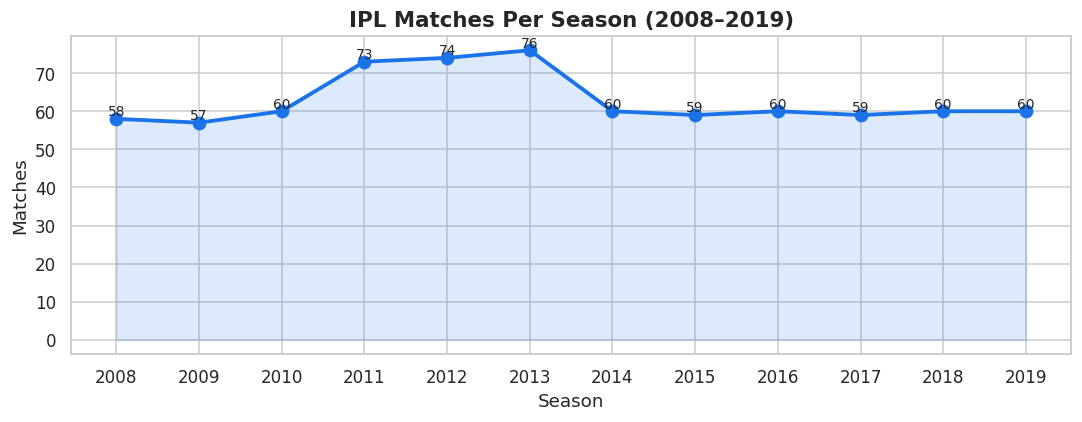

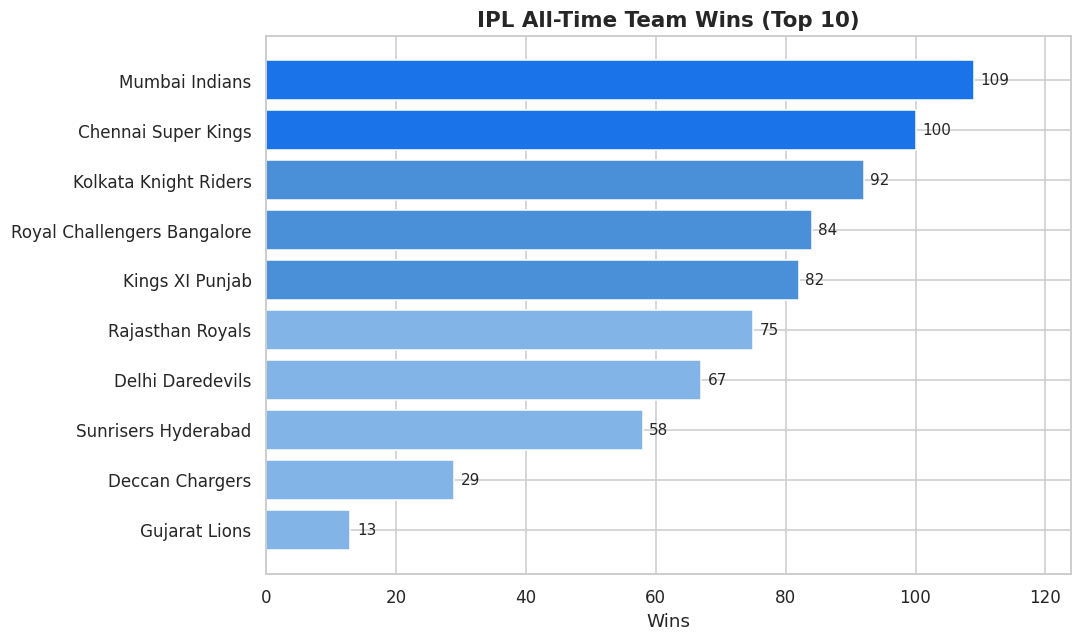

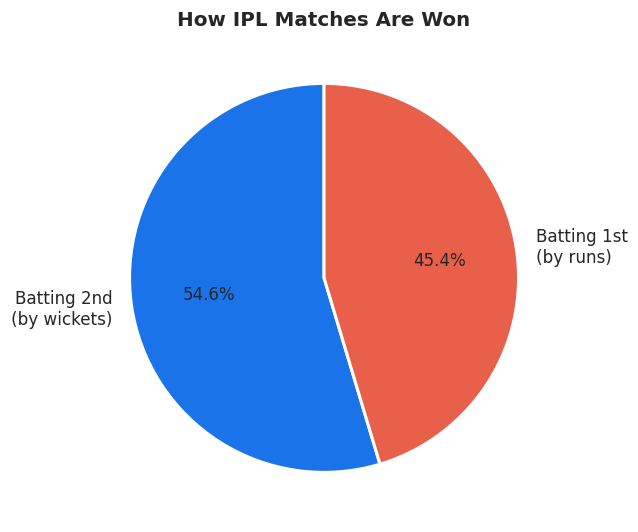

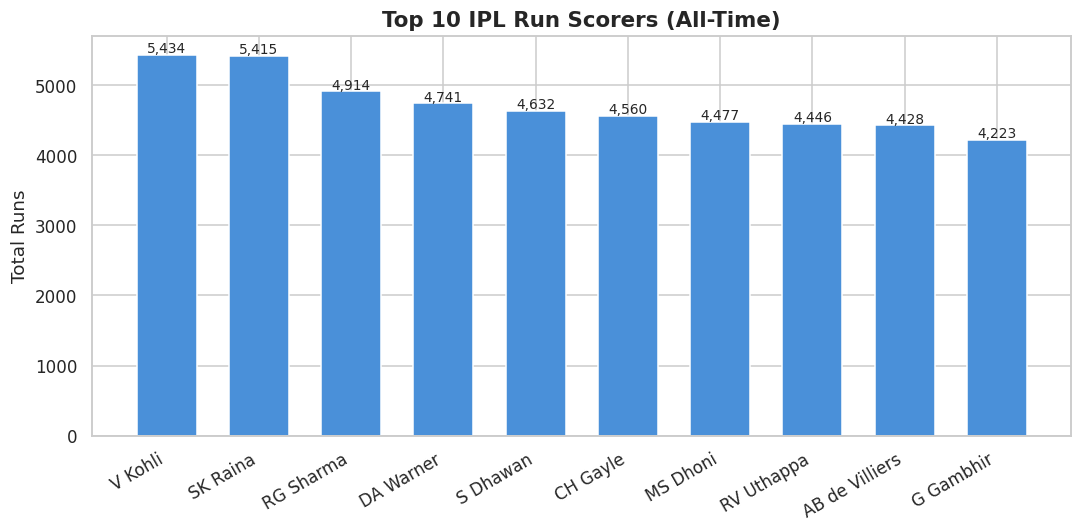

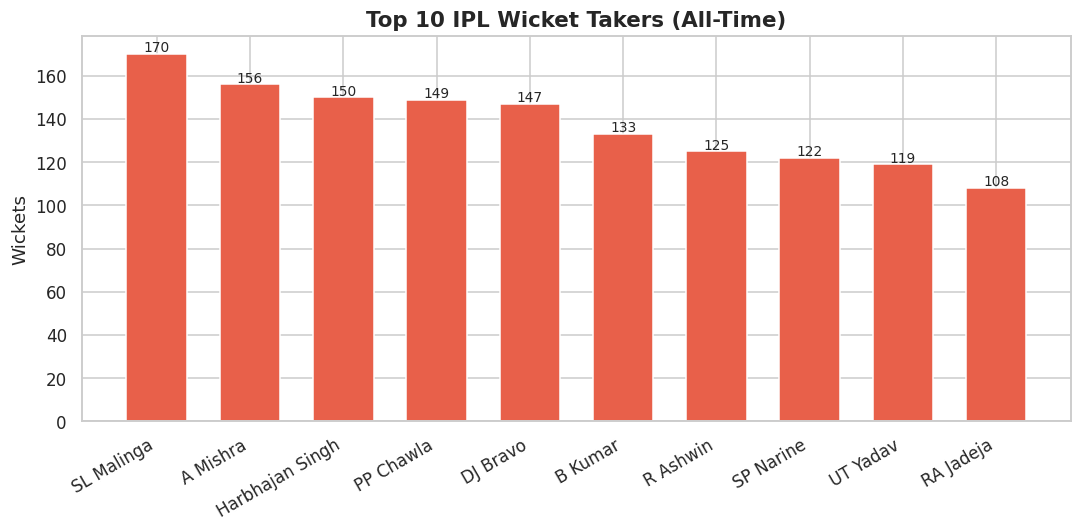

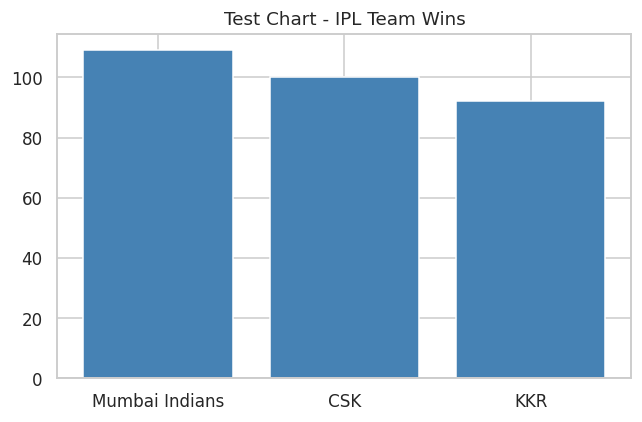

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

# Simple test chart
plt.figure(figsize=(6,4))
plt.bar(['Mumbai Indians', 'CSK', 'KKR'], [109, 100, 92], color='steelblue')
plt.title('Test Chart - IPL Team Wins')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# This loads the CSV files uploaded to Colab
matches = pd.read_csv('/content/matches.csv')
deliveries = pd.read_csv('/content/deliveries.csv')

print("matches loaded:", matches.shape)
print("deliveries loaded:", deliveries.shape)

matches loaded: (756, 18)
deliveries loaded: (179078, 21)
